Assignment: K-Medoids Clustering Algorithm using Python

In [6]:
# -----------------------------------------------------------
# Assignment: K-Medoids Clustering Algorithm using Python
# (Manual Implementation — No sklearn-extra needed)
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [7]:
# -----------------------------------------------------------
# Step 1: Create Dataset
# -----------------------------------------------------------

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# -----------------------------------------------------------
# Step 2: Helper Function — Distance Matrix
# -----------------------------------------------------------

def compute_distance_matrix(X):
    m = X.shape[0]
    dist_matrix = np.zeros((m, m))
    for i in range(m):
        for j in range(m):
            dist_matrix[i][j] = np.linalg.norm(X[i] - X[j])
    return dist_matrix

In [9]:
# -----------------------------------------------------------
# Step 3: Manual K-Medoids Algorithm
# -----------------------------------------------------------

def k_medoids(X, k, max_iter=100):
    m = X.shape[0]
    distance_matrix = compute_distance_matrix(X)
    
    # Initialize medoids randomly
    medoid_indices = np.random.choice(m, k, replace=False)
    
    for _ in range(max_iter):
        # Assign points to nearest medoid
        clusters = {}
        for i in range(k):
            clusters[i] = []
        
        for i in range(m):
            distances_to_medoids = [distance_matrix[i][medoid] for medoid in medoid_indices]
            cluster = np.argmin(distances_to_medoids)
            clusters[cluster].append(i)
        
        # Update medoids
        new_medoids = []
        for i in range(k):
            cluster_points = clusters[i]
            intra_distances = np.sum(distance_matrix[np.ix_(cluster_points, cluster_points)], axis=1)
            new_medoid = cluster_points[np.argmin(intra_distances)]
            new_medoids.append(new_medoid)
        
        if np.array_equal(medoid_indices, new_medoids):
            break
        medoid_indices = new_medoids
    
    # Create labels
    labels = np.zeros(m)
    for cluster, points in clusters.items():
        for p in points:
            labels[p] = cluster
    return np.array(medoid_indices), labels


In [10]:
# -----------------------------------------------------------
# Step 4: Apply Algorithm
# -----------------------------------------------------------

k = 4
medoid_indices, labels = k_medoids(X_scaled, k)
medoids = X_scaled[medoid_indices]

# -----------------------------------------------------------
# Step 5: Evaluation
# -----------------------------------------------------------

silhouette = silhouette_score(X_scaled, labels)
print(f"\n✅ Silhouette Score: {silhouette:.3f}")
print("\n🔹 Medoid Coordinates:")
print(medoids)


✅ Silhouette Score: 0.880

🔹 Medoid Coordinates:
[[-1.03238876  0.70774005]
 [ 1.5390652  -0.13035808]
 [ 0.15766508  0.96685187]
 [-0.66625582 -1.56778579]]


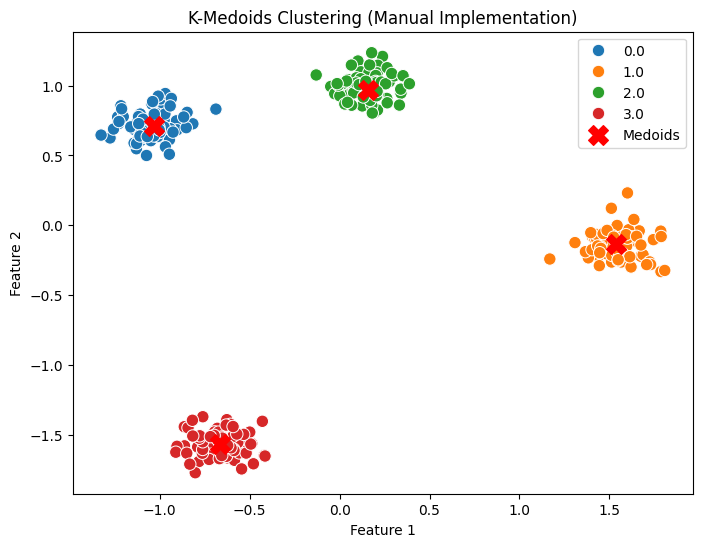

In [11]:
# -----------------------------------------------------------
# Step 6: Visualization
# -----------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels, palette='tab10', s=80)
plt.scatter(medoids[:,0], medoids[:,1], s=200, c='red', marker='X', label='Medoids')
plt.title('K-Medoids Clustering (Manual Implementation)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()